# Week 1: Data Exploration & Preprocessing

## Internship: Machine Learning (CodGen Technologies)

**Name:** Shivansh Mishra

**Dataset:** Titanic Dataset

**Objective:**
The objective of this notebook is to load, explore, preprocess, and visualize the Titanic dataset as part of Week 1 of the Machine Learning Internship.

In [4]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
# Load the Titanic dataset

df = pd.read_csv("Titanic-Dataset.csv")

# Display the first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Task 1: Explore the Dataset

In this section, we explore the Titanic dataset by examining its dimensions, data types, summary statistics, and missing values. This helps us understand the dataset before performing preprocessing.

In [6]:
# Check the number of rows and columns

df.shape

(891, 12)

In [7]:
# Display data types of all columns

df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [8]:
# Display summary statistics

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
# Check for missing values

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Task 2: Handle Missing Values

The dataset contains missing values in the following columns:

- Age: 177 missing values
- Cabin: 687 missing values
- Embarked: 2 missing values

Handling strategy:

- **Age:** Filled missing values using the median because it is robust to outliers.
- **Cabin:** Dropped the column because more than 75% of the values are missing.
- **Embarked:** Filled missing values using the mode since it is a categorical feature.

In [10]:
# Fill missing values in Age using median

df["Age"] = df["Age"].fillna(df["Age"].median())

In [11]:
# Fill missing values in Embarked using mode

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [12]:
# Drop Cabin column

df.drop("Cabin", axis=1, inplace=True)

In [13]:
# Check if missing values have been handled

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# Task 3: Encode Categorical Features

Machine Learning algorithms cannot understand text (categorical) data directly. Therefore, categorical columns are converted into numerical values using encoding techniques.

In this dataset:
- Label Encoding is used for the `Sex` column because it has only two categories (Male and Female).
- One-Hot Encoding is used for the `Embarked` column because it has three categories (C, Q, and S), and there is no natural order among them.

In [14]:
# Display categorical columns

df.select_dtypes(include="object")

C:\Users\Shivansh Mishra\AppData\Local\Temp\ipykernel_31624\1033258415.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object")


,Name,Sex,Ticket,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,S
4,"Allen, Mr. William Henry",male,373450,S
...,...,...,...,...
886,"Montvila, Rev. Juozas",male,211536,S
887,"Graham, Miss. Margaret Edith",female,112053,S
888,"Johnston, Miss. Catherine Helen ""Carrie""",female,W./C. 6607,S
889,"Behr, Mr. Karl Howell",male,111369,C


In [15]:
# Check unique values in categorical columns

print("Sex:", df["Sex"].unique())
print("Embarked:", df["Embarked"].unique())

Sex: <StringArray>
['male', 'female']
Length: 2, dtype: str
Embarked: <StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str


In [16]:
# Label Encode the Sex column

df["Sex"] = df["Sex"].map({
    "male": 1,
    "female": 0
})

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,S


In [17]:
# One-Hot Encode the Embarked column

df = pd.get_dummies(df, columns=["Embarked"], dtype=int)

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,0,0,1
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,0,0,1


# Removing Irrelevant Features

The `Name` and `Ticket` columns are removed because they contain unique textual information that does not contribute significantly to predicting passenger survival. Removing such features simplifies the dataset and improves model efficiency.

In [18]:
# Remove unnecessary columns

df = df.drop(["Name", "Ticket"], axis=1)

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,1,22.0,1,0,7.2500,0,0,1
1,2,1,1,0,38.0,1,0,71.2833,1,0,0
2,3,1,3,0,26.0,0,0,7.9250,0,0,1
3,4,1,1,0,35.0,1,0,53.1000,0,0,1
4,5,0,3,1,35.0,0,0,8.0500,0,0,1


# Task 4: Data Visualization

Data visualization helps us understand the distribution, relationships, and important patterns in the dataset before building a machine learning model.

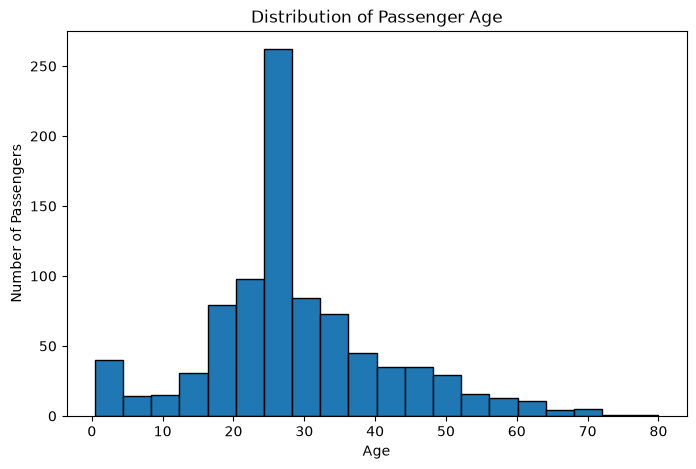

In [19]:
# Histogram of Age

plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20, edgecolor="black")

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

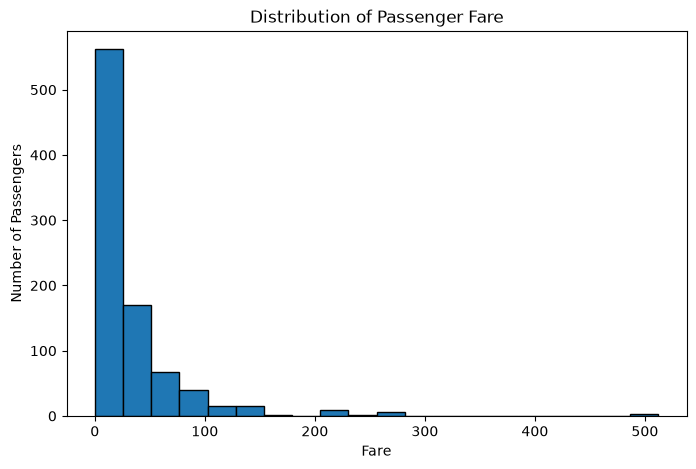

In [20]:
# Histogram of Fare

plt.figure(figsize=(8,5))
plt.hist(df["Fare"], bins=20, edgecolor="black")

plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

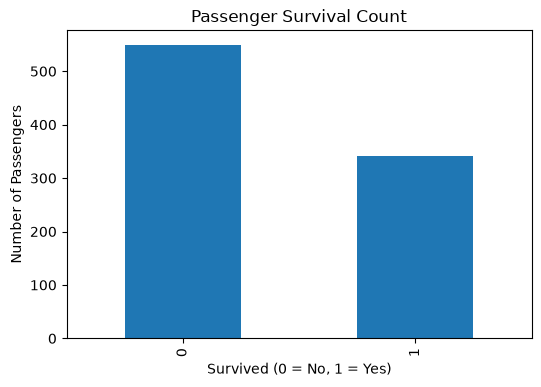

In [21]:
# Bar chart of Survival

plt.figure(figsize=(6,4))
df["Survived"].value_counts().plot(kind="bar")

plt.title("Passenger Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

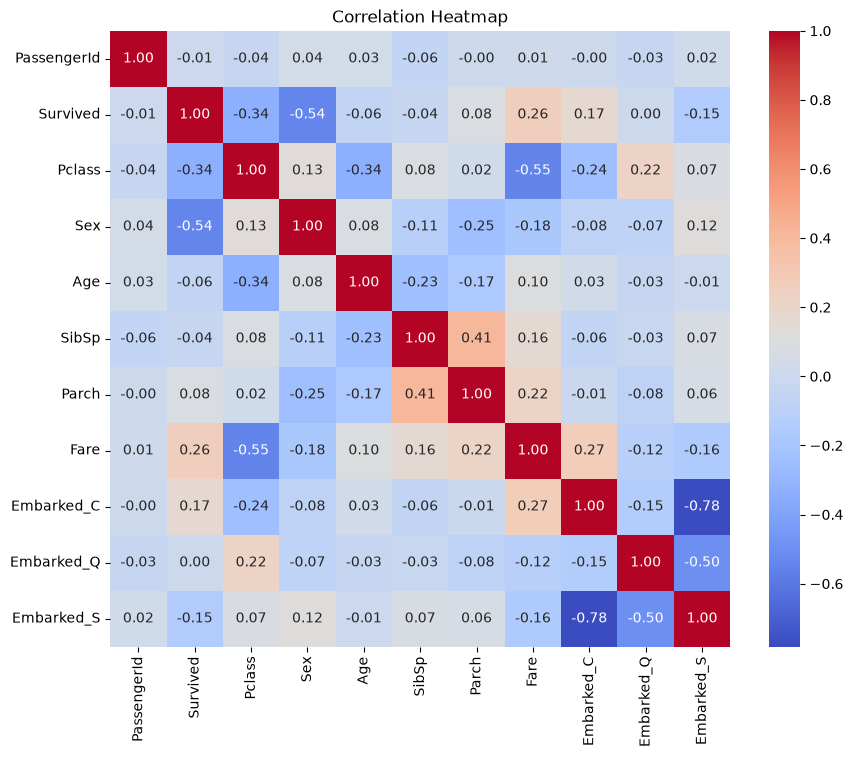

In [22]:
# Correlation Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

# Task 5: Observations

## Key Observations

1. The dataset contains **891 passengers** and initially had **12 features**. After preprocessing, irrelevant columns (`Name`, `Ticket`, and `Cabin`) were removed or handled appropriately.

2. The `Age` column had missing values, which were filled using the **median**, while the `Embarked` column was filled using the **mode**. The `Cabin` column was removed because it contained too many missing values.

3. The **Age histogram** shows that most passengers were young adults, mainly between **20 and 40 years** of age.

4. The **Fare histogram** indicates that most passengers paid lower ticket fares, while only a few passengers paid very high fares, showing the presence of outliers.

5. The **Survival bar chart** shows that more passengers did not survive than survived.

6. The **Correlation Heatmap** shows that some features, such as `Fare` and `Pclass`, have a noticeable relationship with passenger survival, while others have weak correlations.

## Conclusion

The Titanic dataset has been successfully cleaned and preprocessed. Missing values were handled, categorical variables were encoded, unnecessary features were removed, and visualizations were created to better understand the data. The dataset is now ready for machine learning model development.